# Final Project - Chem 277B
### **Structure-Aware Resistance Prediction in Mycobacterium tuberculosis via MIC Regression**

### Contributors:
Cris Zong, Ethan Chan, Isabella Beatrice Bonomi, Robert Craig Wallace, Sidney Alexa Brooks

### 1) Objective and Goal of the Project

Objective: To develop a machine learning model that predicts M. tuberculosis drug resistance by jointly encoding mutation profiles and drug molecular structure, rather than treating each drug as an independent categorical label.

Goal: To accurately predict resistance confidence levels from mutation loci and Morgan fingerprints, and ultimately generalize to novel anti-TB compounds not present in existing catalogues.

**Note:** prior to going through this walkthrough, instructions for downloading data will be included in the README markdown file.

In [2]:
# Import standard libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pubchempy as pcp
import tarfile

from sklearn.preprocessing import StandardScaler
from statsmodels.api import add_constant, OLS, Logit
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from rdkit import Chem
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator
from rdkit.DataStructs import ConvertToNumpyArray


In [3]:
# Load training data
master_file = pd.read_csv("WHO-UCN-TB-2023.6-eng_catalogue_master_file.txt", sep="\t")

# Let's take a look at the data
master_file.head()

/var/folders/pp/jcwfn_w55v39gn9_lbws6_fw0000gn/T/ipykernel_73058/2361419187.py:2: DtypeWarning: Columns (36,37,99,100,102,103,106,108,112) have mixed types. Specify dtype option on import or set low_memory=False.
  master_file = pd.read_csv("WHO-UCN-TB-2023.6-eng_catalogue_master_file.txt", sep="\t")


,drug,gene,mutation,variant,tier,effect,genomic position,algorithm_pass_DATASET ALL,Present_SOLO_SR_DATASET ALL,Present_SOLO_R_DATASET ALL,...,Additional grading criteria applied,FINAL CONFIDENCE GRADING,Comment,CHANGES vs ver1,"Relaxed thresholds simulation (BDQ_Rv0678, CFZ_Rv0678, INH_katG, DLM_ddn/fbiA/fbiB/fbiC/fgd1/Rv2983)",Silent mutation,Listed in abridged tables,Additional grading,Footnote,CHANGES vs ver1.1
0,Amikacin,bacA,c.102G>A,bacA_c.102G>A,2,synonymous_variant,"(see ""Genomic_coordinates"" sheet)",NaN,NaN,NaN,...,Silent mutation,4) Not assoc w R - Interim,NaN,Now listed,NaN,Silent mutation,no,NaN,NaN,0
1,Amikacin,bacA,c.1044G>A,bacA_c.1044G>A,2,synonymous_variant,"(see ""Genomic_coordinates"" sheet)",NaN,NaN,NaN,...,NaN,5) Not assoc w R,NaN,Now listed,NaN,Silent mutation,no,NaN,NaN,0
2,Amikacin,bacA,c.105C>G,bacA_c.105C>G,2,synonymous_variant,"(see ""Genomic_coordinates"" sheet)",NaN,NaN,NaN,...,Silent mutation,4) Not assoc w R - Interim,NaN,Now listed,NaN,Silent mutation,no,NaN,NaN,0
3,Amikacin,bacA,c.1065T>G,bacA_c.1065T>G,2,synonymous_variant,"(see ""Genomic_coordinates"" sheet)",NaN,NaN,NaN,...,Silent mutation,4) Not assoc w R - Interim,NaN,Now listed,NaN,Silent mutation,no,NaN,NaN,0
4,Amikacin,bacA,c.1080G>A,bacA_c.1080G>A,2,synonymous_variant,"(see ""Genomic_coordinates"" sheet)",NaN,NaN,NaN,...,Silent mutation,4) Not assoc w R - Interim,NaN,Now listed,NaN,Silent mutation,no,NaN,NaN,0


In [4]:
#variants_excel = pd.read_excel("WHO-UCN-TB-2023.7-eng.xlsx", skiprows=2)

# Let's take a look at the data
# variants_excel.head()

# removed to only look at the full dataset first

In [5]:
# check distribution of WHO grades
print(master_file["FINAL CONFIDENCE GRADING"].value_counts().sort_index())
print(master_file["FINAL CONFIDENCE GRADING"].value_counts(normalize=True).sort_index()) # most of the grades Uncertain significance, this could be an issue

FINAL CONFIDENCE GRADING
1) Assoc w R                    253
2) Assoc w R - Interim         1130
3) Uncertain significance     33906
4) Not assoc w R - Interim    12379
5) Not assoc w R                484
Name: count, dtype: int64
FINAL CONFIDENCE GRADING
1) Assoc w R                  0.005254
2) Assoc w R - Interim        0.023467
3) Uncertain significance     0.704145
4) Not assoc w R - Interim    0.257082
5) Not assoc w R              0.010052
Name: proportion, dtype: float64


### 2) Data Cleaning and Ordinal Encoding

In [6]:
# look at the columns of the master file and filter relevant rows
#print(master_file.columns)

master_file_clean = master_file.dropna(subset=["mutation", "drug", "FINAL CONFIDENCE GRADING"])

# standardize the strings
master_file_clean["mutation"] = master_file_clean["mutation"].str.strip() # may need further data cleaning for "?" characters
master_file_clean["drug"] = master_file_clean["drug"].str.strip()
master_file_clean["FINAL CONFIDENCE GRADING"] = master_file_clean["FINAL CONFIDENCE GRADING"].str.strip()

print(master_file_clean["FINAL CONFIDENCE GRADING"].unique())

# ordinally encode resistance grades
grading_scheme = {
    "5) Not assoc w R": 0,
    "4) Not assoc w R - Interim": 1,
    "3) Uncertain significance": 2,
    "2) Assoc w R - Interim": 3,
    "1) Assoc w R": 4
}

master_file_clean["grade_ordinal"] = master_file_clean["FINAL CONFIDENCE GRADING"].map(grading_scheme)
master_file_clean = master_file_clean.dropna(subset=["grade_ordinal"])

# remove duplicates
master_file_clean = master_file_clean.drop_duplicates(subset=["mutation", "drug"])
#print(master_file_clean)

# keep only necessary columns
model_df = master_file_clean[[
    "mutation",
    "gene",
    "drug",
    "FINAL CONFIDENCE GRADING",
    "grade_ordinal"
]].copy()

model_df.head()

print(model_df["drug"].unique())

['4) Not assoc w R - Interim' '5) Not assoc w R'
 '3) Uncertain significance' '2) Assoc w R - Interim' '1) Assoc w R']
['Amikacin' 'Bedaquiline' 'Capreomycin' 'Clofazimine' 'Delamanid'
 'Ethambutol' 'Ethionamide' 'Isoniazid' 'Kanamycin' 'Levofloxacin'
 'Linezolid' 'Moxifloxacin' 'Pyrazinamide' 'Rifampicin' 'Streptomycin']


In [7]:
drug_list = ['Amikacin', 'Bedaquiline', 'Capreomycin', 'Clofazimine', 'Delamanid',
             'Ethambutol', 'Ethionamide', 'Isoniazid', 'Kanamycin', 'Levofloxacin', 
             'Linezolid', 'Moxifloxacin', 'Pyrazinamide', 'Rifampicin', 'Streptomycin']

# get the smiles for the drugs
def get_smiles(drug_name):
    try:
        compounds = pcp.get_compounds(drug_name, "name")
        if len(compounds) > 0:
            return compounds[0].connectivity_smiles
    except:
        return None
    return None

#apply to the list of TB drugs
TB_drugs = pd.DataFrame({"drug": drug_list})
TB_drugs['smiles'] = TB_drugs["drug"].apply(get_smiles)

# add fingerprints to dataset
morgan_generator = GetMorganGenerator(radius=2, fpSize=2048)

def smiles_to_fingerprint(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    fingerprint = morgan_generator.GetFingerprint(mol)
    array = np.zeros((2048, ), dtype=int)
    ConvertToNumpyArray(fingerprint, array)
    
    return array

TB_drugs["fingerprint"] = TB_drugs["smiles"].apply(smiles_to_fingerprint)

# merge drugs to the model df
final_data = model_df.merge(TB_drugs, on="drug", how="left")
print(final_data.head())

    mutation  gene      drug    FINAL CONFIDENCE GRADING  grade_ordinal  \
0   c.102G>A  bacA  Amikacin  4) Not assoc w R - Interim              1   
1  c.1044G>A  bacA  Amikacin            5) Not assoc w R              0   
2   c.105C>G  bacA  Amikacin  4) Not assoc w R - Interim              1   
3  c.1065T>G  bacA  Amikacin  4) Not assoc w R - Interim              1   
4  c.1080G>A  bacA  Amikacin  4) Not assoc w R - Interim              1   

                                              smiles  \
0  C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...   
1  C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...   
2  C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...   
3  C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...   
4  C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...   

                                         fingerprint  
0  [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...  
1  [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...  
2  [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0

In [8]:
final_data_copy = final_data.dropna(subset=["fingerprint"]).copy()
final_data_copy.head()


,mutation,gene,drug,FINAL CONFIDENCE GRADING,grade_ordinal,smiles,fingerprint
0,c.102G>A,bacA,Amikacin,4) Not assoc w R - Interim,1,C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,c.1044G>A,bacA,Amikacin,5) Not assoc w R,0,C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,c.105C>G,bacA,Amikacin,4) Not assoc w R - Interim,1,C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,c.1065T>G,bacA,Amikacin,4) Not assoc w R - Interim,1,C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,c.1080G>A,bacA,Amikacin,4) Not assoc w R - Interim,1,C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [9]:
final_data_df = pd.DataFrame(final_data_copy["fingerprint"].tolist(), index=final_data_copy.index)
final_data_df.columns = [f"fp_{i}" for i in range(final_data_df.shape[1])] # change the fingerprints from an array to columns

final_ml = pd.concat([final_data.drop(columns=["fingerprint"]), final_data_df], axis=1)
print(final_ml.shape)
final_ml.head()

(45620, 2054)


,mutation,gene,drug,FINAL CONFIDENCE GRADING,grade_ordinal,smiles,fp_0,fp_1,fp_2,fp_3,...,fp_2038,fp_2039,fp_2040,fp_2041,fp_2042,fp_2043,fp_2044,fp_2045,fp_2046,fp_2047
0,c.102G>A,bacA,Amikacin,4) Not assoc w R - Interim,1,C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,c.1044G>A,bacA,Amikacin,5) Not assoc w R,0,C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,c.105C>G,bacA,Amikacin,4) Not assoc w R - Interim,1,C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,c.1065T>G,bacA,Amikacin,4) Not assoc w R - Interim,1,C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
4,c.1080G>A,bacA,Amikacin,4) Not assoc w R - Interim,1,C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0


In [10]:
# check distribution of grades
print(final_ml["grade_ordinal"].value_counts().sort_index())
print(final_ml["grade_ordinal"].value_counts(normalize=True).sort_index()) # most of the grades are 2...Uncertain significance

grade_ordinal
0      453
1    10806
2    32998
3     1119
4      244
Name: count, dtype: int64
grade_ordinal
0    0.009930
1    0.236870
2    0.723323
3    0.024529
4    0.005349
Name: proportion, dtype: float64


# Add visualizations HERE
## PCA, Umap etc - Sidney

### 3) Build a baseline model

In [11]:
# take a subset of the data to only look at gene, drug, and WHO grade for resistance
baseline_data = final_ml[["gene", "drug", "grade_ordinal"]].copy()
print(baseline_data.head())

x_base = baseline_data[["gene", "drug"]]
y_base = baseline_data["grade_ordinal"]

X_encoded = pd.get_dummies(x_base, columns=["gene", "drug"]) # change to one hot encoding 

# split training and test data
Xb_train, Xb_test, yb_train, yb_test = train_test_split(X_encoded, y_base, test_size=0.2, random_state=42, stratify=y_base)


   gene      drug  grade_ordinal
0  bacA  Amikacin              1
1  bacA  Amikacin              0
2  bacA  Amikacin              1
3  bacA  Amikacin              1
4  bacA  Amikacin              1


              precision    recall  f1-score   support

           0       0.02      0.44      0.04        90
           1       0.35      0.54      0.42      2161
           2       0.84      0.28      0.42      6600
           3       0.18      0.68      0.28       224
           4       0.04      0.67      0.08        49

    accuracy                           0.36      9124
   macro avg       0.29      0.52      0.25      9124
weighted avg       0.70      0.36      0.41      9124

Accuracy: 0.36


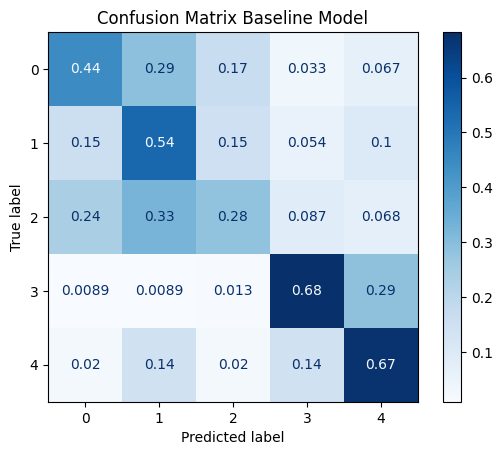

In [12]:
# Fit a baseline logistic regression model, balance the data for each class
baseline_model = LogisticRegression(max_iter=2000, class_weight="balanced")
baseline_model.fit(Xb_train, yb_train)

# predict resistance class
y_pred = baseline_model.predict(Xb_test)

print(classification_report(yb_test, y_pred))

# Display the accuracy
accuracy = np.mean(yb_test == y_pred)
print(f'Accuracy: {accuracy:.2f}')

# Plot the confusion matrix
labels = [0, 1, 2, 3, 4]
cm = confusion_matrix(yb_test, y_pred, normalize = 'true', labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix = cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix Baseline Model")
plt.show()

### 4) Test with mutation data - instead of genes, let's look at mutations

              precision    recall  f1-score   support

           0       0.23      0.32      0.27        90
           1       0.79      0.77      0.78      2161
           2       0.91      0.83      0.87      6600
           3       0.17      0.33      0.22       224
           4       0.06      0.55      0.11        49

    accuracy                           0.80      9124
   macro avg       0.43      0.56      0.45      9124
weighted avg       0.85      0.80      0.82      9124

Accuracy: 0.80


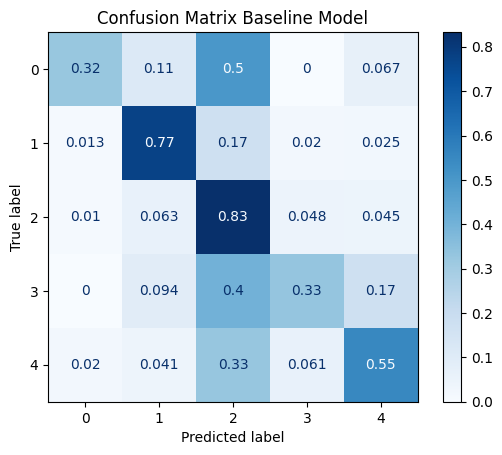

In [13]:
# test another baseline logistic regression model to look at mutation data and drug resistance 
mutation_baseline = final_ml[["mutation", "drug", "grade_ordinal"]].dropna().copy()

x_base = mutation_baseline[["mutation", "drug"]]
y_base = mutation_baseline["grade_ordinal"]

# split test and training data
Xb_train, Xb_test, yb_train, yb_test = train_test_split(x_base, y_base, test_size=0.2, random_state=42, stratify=y_base)

# Use sparse one hot encoding for genetic mutations
preprocessor = ColumnTransformer(transformers=[("cat", OneHotEncoder(handle_unknown="ignore"), ["mutation", "drug"])])
mutation_model = Pipeline([("preprocessor", preprocessor), ("classifier", LogisticRegression(max_iter=2000, class_weight="balanced"))])

# fit the model
mutation_model.fit(Xb_train, yb_train)

# predict the resistance labels
y_pred = mutation_model.predict(Xb_test)

print(classification_report(yb_test, y_pred))

# Display the accuracy
accuracy = np.mean(yb_test == y_pred)
print(f'Accuracy: {accuracy:.2f}')

# Plot the confusion matrix
labels = [0, 1, 2, 3, 4]
cm = confusion_matrix(yb_test, y_pred, normalize = 'true', labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix = cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix Baseline Model")
plt.show()


In [46]:
# Limit data to only top mutations 
print(final_ml["mutation"].nunique())
print(final_ml["mutation"].value_counts().head(10))


24100
mutation
LoF          15
deletion     14
p.Met1?      14
c.309C>T     13
c.189C>T     12
c.1122G>A    12
c.312C>T     12
c.198C>T     12
c.1212G>A    11
c.195G>A     11
Name: count, dtype: int64


In [47]:
with tarfile.open('card-data.tar.bz2') as tar:
    tar.extractall(path="./extracted_files")
    

### 4.1) LightGBM and XGBoost — Gradient Boosting Comparison
We compare tree-based gradient boosting (LightGBM, XGBoost) against logistic regression to test whether nonlinear models improve on the mutation + drug classification task. Both boosting models use `compute_sample_weight("balanced")` to handle class imbalance and are tuned for the ultra-sparse one-hot feature space (~21K columns).

In [ ]:
import lightgbm as lgb
from xgboost import XGBClassifier

# Prepare the same mutation + drug features used by the logistic regression model
mutation_baseline = final_ml[["mutation", "drug", "grade_ordinal"]].dropna().copy()

x_base = mutation_baseline[["mutation", "drug"]]
y_base = mutation_baseline["grade_ordinal"].astype(int)

# One-hot encode (sparse) — reuse for both models
preprocessor = ColumnTransformer(
    transformers=[("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=True), ["mutation", "drug"])]
)

# Train/test split (same seed as before)
Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    x_base, y_base, test_size=0.2, random_state=42, stratify=y_base
)

# Fit the preprocessor on training data and transform both splits
Xb_train_enc = preprocessor.fit_transform(Xb_train)
Xb_test_enc = preprocessor.transform(Xb_test)

Training until validation scores don't improve for 50 rounds
[100]	valid_0's multi_logloss: 1.48086
[200]	valid_0's multi_logloss: 1.48011
Early stopping, best iteration is:
[209]	valid_0's multi_logloss: 1.48007
=== LightGBM Classification Report ===
              precision    recall  f1-score   support

           0       0.03      0.26      0.05        90
           1       0.30      0.55      0.39      2161
           2       0.81      0.24      0.37      6600
           3       0.06      0.49      0.11       224
           4       0.06      0.57      0.10        49

    accuracy                           0.32      9124
   macro avg       0.25      0.42      0.20      9124
weighted avg       0.66      0.32      0.36      9124

Accuracy: 0.32


/Users/yijianzong/opt/anaconda3/envs/tb_ml/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


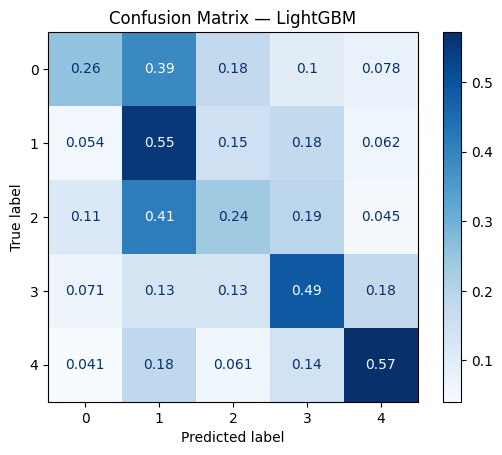

In [ ]:
# --- LightGBM ---
from sklearn.utils.class_weight import compute_sample_weight

# Use balanced sample weights
lgb_sample_weights = compute_sample_weight("balanced", yb_train)

lgb_model = lgb.LGBMClassifier(
    objective="multiclass",
    num_class=5,
    n_estimators=1000,
    learning_rate=0.1,
    num_leaves=31,
    max_depth=6,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.3,       # important: low value for ultra-sparse one-hot features
    reg_alpha=1.0,               # L1 regularization to handle sparsity
    reg_lambda=1.0,              # L2 regularization
    random_state=42,
    verbose=-1,
    n_jobs=-1,
)

lgb_model.fit(
    Xb_train_enc, yb_train,
    sample_weight=lgb_sample_weights,
    eval_set=[(Xb_test_enc, yb_test)],
    callbacks=[lgb.log_evaluation(period=100), lgb.early_stopping(50)],
)

y_pred_lgb = lgb_model.predict(Xb_test_enc)

print("=== LightGBM Classification Report ===")
print(classification_report(yb_test, y_pred_lgb))
print(f"Accuracy: {np.mean(yb_test == y_pred_lgb):.2f}")

# Confusion matrix
cm_lgb = confusion_matrix(yb_test, y_pred_lgb, normalize="true", labels=[0, 1, 2, 3, 4])
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lgb)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix — LightGBM")
plt.show()

[0]	validation_0-mlogloss:1.60153
[100]	validation_0-mlogloss:1.39810
[200]	validation_0-mlogloss:1.34256
[300]	validation_0-mlogloss:1.30483
[400]	validation_0-mlogloss:1.27881
[500]	validation_0-mlogloss:1.25576
[600]	validation_0-mlogloss:1.23420
[700]	validation_0-mlogloss:1.21662
[800]	validation_0-mlogloss:1.20117
[900]	validation_0-mlogloss:1.18814
[999]	validation_0-mlogloss:1.17461
=== XGBoost Classification Report ===
              precision    recall  f1-score   support

           0       0.29      0.24      0.27        90
           1       0.30      0.63      0.40      2161
           2       0.82      0.35      0.49      6600
           3       0.07      0.54      0.13       224
           4       0.50      0.04      0.08        49

    accuracy                           0.42      9124
   macro avg       0.40      0.36      0.27      9124
weighted avg       0.67      0.42      0.45      9124

Accuracy: 0.42


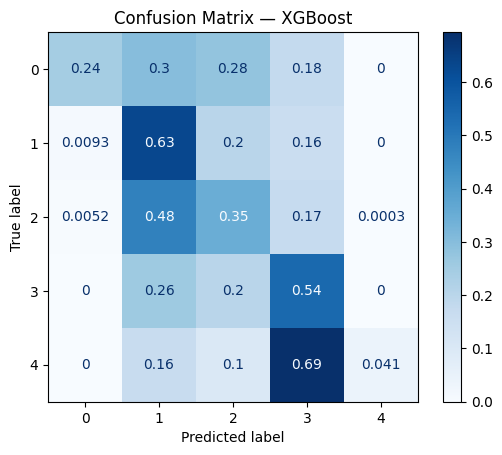

In [16]:
# --- XGBoost ---
sample_weights = compute_sample_weight("balanced", yb_train)

xgb_model = XGBClassifier(
    objective="multi:softmax",
    num_class=5,
    n_estimators=1000,
    learning_rate=0.1,
    max_depth=6,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.3,       # low value for ultra-sparse one-hot features
    reg_alpha=1.0,
    reg_lambda=1.0,
    random_state=42,
    eval_metric="mlogloss",
    early_stopping_rounds=50,
    verbosity=0,
    n_jobs=-1,
)

xgb_model.fit(
    Xb_train_enc, yb_train,
    sample_weight=sample_weights,
    eval_set=[(Xb_test_enc, yb_test)],
    verbose=100,
)

y_pred_xgb = xgb_model.predict(Xb_test_enc)

print("=== XGBoost Classification Report ===")
print(classification_report(yb_test, y_pred_xgb))
print(f"Accuracy: {np.mean(yb_test == y_pred_xgb):.2f}")

# Confusion matrix
cm_xgb = confusion_matrix(yb_test, y_pred_xgb, normalize="true", labels=[0, 1, 2, 3, 4])
disp = ConfusionMatrixDisplay(confusion_matrix=cm_xgb)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix — XGBoost")
plt.show()

In [17]:
# --- Side-by-side comparison ---
from sklearn.metrics import f1_score

models = {
    "Logistic Regression": mutation_model.predict(Xb_test),
    "LightGBM": y_pred_lgb,
    "XGBoost": y_pred_xgb,
}

comparison = []
for name, preds in models.items():
    comparison.append({
        "Model": name,
        "Accuracy": np.mean(yb_test == preds),
        "Macro F1": f1_score(yb_test, preds, average="macro"),
        "Weighted F1": f1_score(yb_test, preds, average="weighted"),
    })

comparison_df = pd.DataFrame(comparison).set_index("Model")
print(comparison_df.round(3))

                     Accuracy  Macro F1  Weighted F1
Model                                               
Logistic Regression     0.800     0.452        0.824
LightGBM                0.320     0.202        0.361
XGBoost                 0.416     0.272        0.454


### 4.2) Gradient Boosting Analysis

#### Key Result

| Model | Accuracy | Macro F1 | Weighted F1 |
|---|---|---|---|
| Logistic Regression | **0.800** | **0.452** | **0.824** |
| XGBoost | 0.416 | 0.272 | 0.454 |
| LightGBM | 0.320 | 0.202 | 0.361 |

Logistic regression outperforms both gradient boosting models across all metrics.

#### Interpretations for Poor Performances

##### Sparse Matrix
Our feature matrix contains ~21K one-hot encoded columns (24K unique mutations + 15 drugs). Logistic regression handles this well since each mutation gets its own learned coefficient, so even a mutation seen once can contribute to prediction. However, tree-based models split features one at a time. When 99% of a one-hot column is zero, the split gives almost no information gain. To approximate what logistic regression does in a single linear combination, trees need many sequential splits.

##### Class Imbalance

The dataset is heavily skewed (72% class 2 "Uncertain significance"). When we apply balanced sample weights, logistic regression adjusts its loss function smoothly — it learns good coefficients for the majority class while giving minority classes more weight. The boosting models, however, over-correct: XGBoost's recall on class 2 drops from 83% (LR) to 35%, meaning it misclassifies 65% of the majority class. Meanwhile, minority classes gain recall (e.g., class 1: 0.63, class 3: 0.54) but at very low precision (0.30 and 0.07 respectively). This trade-off — sacrificing majority-class accuracy without achieving reliable minority-class precision — drives the lower overall performance.

### 5) Drug Structural Similarity Analysis
Compute pairwise Tanimoto similarity on Morgan fingerprints to identify structurally similar drugs. Tanimoto coefficient is the gold standard in cheminformatics:

$$T(A,B) = \frac{|A \cap B|}{|A \cup B|}$$

After research several relevant sources, a reasonable range of thresholds falls between 0.6 and 0.8. So we choose **0.7** as a threshold to define structurally similarity in drug discovery.

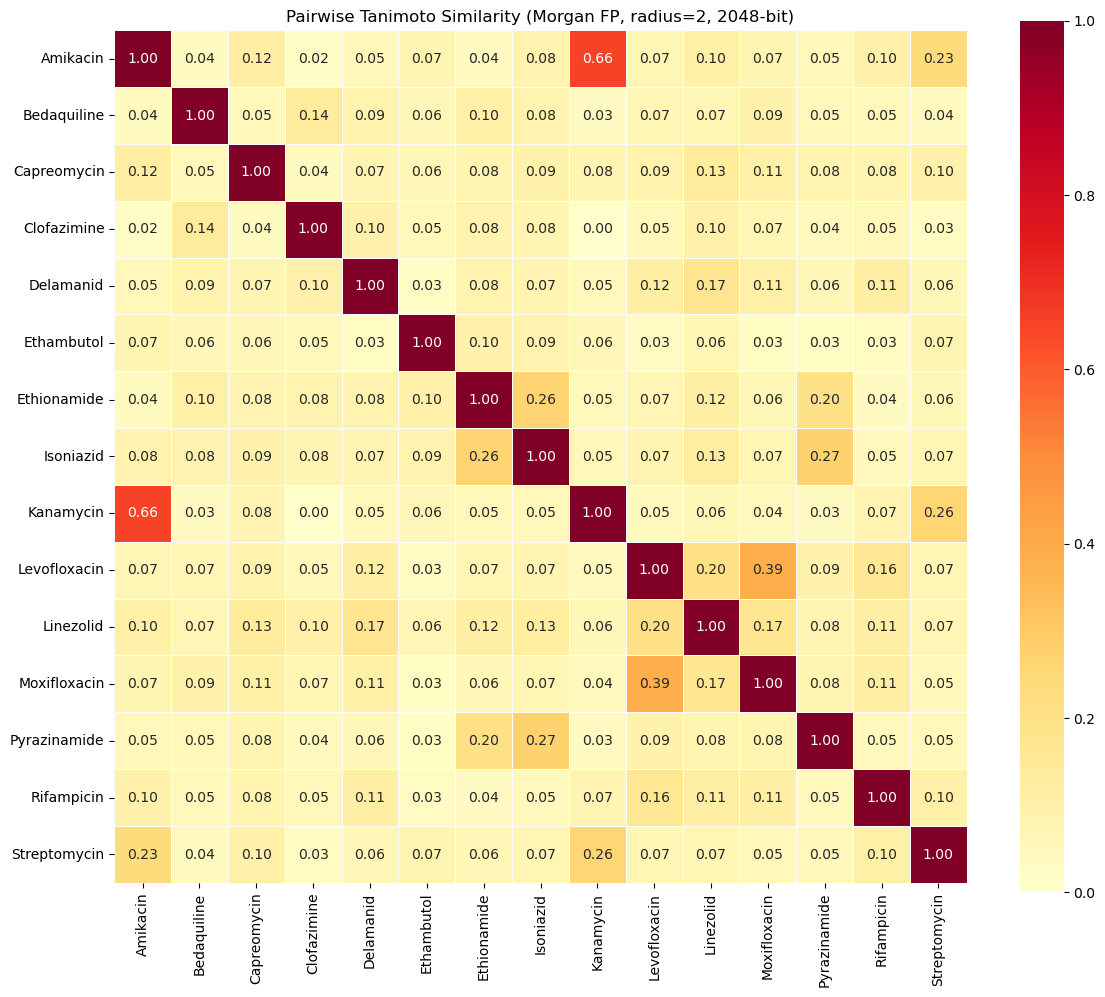


Drug pairs with Tanimoto similarity >= 0.7:
-------------------------------------------------------
  No pairs above threshold.

Total similar pairs: 0


In [48]:
from rdkit import DataStructs
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator

# Generate RDKit fingerprint objects (not numpy arrays) for Tanimoto calculation
morgan_gen = GetMorganGenerator(radius=2, fpSize=2048)

drug_names = TB_drugs["drug"].tolist()
smiles_list = TB_drugs["smiles"].tolist()

# Generate RDKit fingerprint objects for Tanimoto
fps = []
for smi in smiles_list:
    mol = Chem.MolFromSmiles(smi)
    fps.append(morgan_gen.GetFingerprint(mol))

# Compute pairwise Tanimoto similarity matrix
n = len(drug_names)
sim_matrix = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        sim_matrix[i, j] = DataStructs.TanimotoSimilarity(fps[i], fps[j])

sim_df = pd.DataFrame(sim_matrix, index=drug_names, columns=drug_names)

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(sim_df, annot=True, fmt=".2f", cmap="YlOrRd", vmin=0, vmax=1,
            linewidths=0.5, square=True)
plt.title("Pairwise Tanimoto Similarity (Morgan FP, radius=2, 2048-bit)")
plt.tight_layout()
plt.show()

# Identify similar pairs above threshold
THRESHOLD = 0.7
print(f"\nDrug pairs with Tanimoto similarity >= {THRESHOLD}:")
print("-" * 55)
similar_pairs = []
for i in range(n):
    for j in range(i + 1, n):
        if sim_matrix[i, j] >= THRESHOLD:
            similar_pairs.append((drug_names[i], drug_names[j], sim_matrix[i, j]))
            print(f"  {drug_names[i]:15s} — {drug_names[j]:15s}  T = {sim_matrix[i, j]:.3f}")

if not similar_pairs:
    print("  No pairs above threshold.")
print(f"\nTotal similar pairs: {len(similar_pairs)}")

### 5.1) Structural Similarity Findings

We computed pairwise Tanimoto coefficients over Morgan fingerprints (radius=2, 2048-bit) for all 15 anti-TB drugs in the WHO catalogue. A heuristic threshold of T >= 0.7 was used to flag potentially high structural similarity under this fingerprint representation.

**Result:** No drug pair exceeds the 0.7 threshold. The highest observed similarity is **Amikacin–Kanamycin (T = 0.66)**, both aminoglycosides that bind the 30S ribosomal subunit. Other mechanistically related pairs show lower structural overlap:

| Drug Pair | Tanimoto | Drug Class |
|---|---|---|
| Amikacin – Kanamycin | 0.66 | Aminoglycosides (30S ribosome) |
| Levofloxacin – Moxifloxacin | 0.39 | Fluoroquinolones (DNA gyrase) |
| Isoniazid – Pyrazinamide | 0.27 | Small-molecule prodrugs |
| Isoniazid – Ethionamide | 0.26 | Mycolic acid synthesis inhibitors |
| Amikacin – Streptomycin | 0.23 | Aminoglycosides (30S ribosome) |

**Decision:** All 15 drugs are retained. The full dataset (n = 45,620 variant–drug pairs) is used for downstream modeling.

**Analysis:**
Using Morgan fingerprints (radius 2, 2048-bit), we did not observe pairwise Tanimoto similarity above 0.7 among the analyzed drugs. This suggests that, under this 2D fingerprint representation, no pair appears highly redundant by this specific criterion. However, because Tanimoto similarity is fingerprint- and threshold-dependent, this should be interpreted as a preliminary indication of chemical diversity rather than proof that structural redundancy cannot influence downstream modeling.

**Limitation:** Tanimoto similarity on Morgan fingerprints captures 2D substructure overlap but does not reflect pharmacophore or 3D binding-site similarity. Drugs with low Tanimoto scores can still share resistance mechanisms if they bind overlapping protein targets — as is the case for Isoniazid and Ethionamide, which both ultimately inhibit InhA but through different prodrug activation pathways (KatG vs EthA).